<a href="https://colab.research.google.com/github/illostephanie4/sentimental_analysis_using_lstm/blob/main/Sentimental_Analysis_Using_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis with LSTM

## Project Objective
This project aims to build a Sentiment Analysis model using a Long Short-Term Memory (LSTM) neural network to classify movie reviews from the IMDb dataset as Positive (1) or Negative (0).

## Methodology

### 1. Data Loading and Sampling
- The IMDb dataset is loaded using the `datasets` library.
- A sample of 10,000 training entries is extracted from the full training dataset using stratified sampling to ensure a balanced representation of positive and negative reviews.
- The sampled training data is then split into an 80% training set and a 20% validation set, also with stratification.

### 2. Text Processing
- **Tokenization:** Reviews are tokenized into individual words using NLTK's `word_tokenize`.
- **Vocabulary Creation:** A vocabulary of the 20,000 most common words is created, along with special tokens for padding (`<pad>`) and unknown words (`<unk>`).
- **Conversion to Integer Sequences:** Each tokenized review is converted into a sequence of integer IDs based on the created vocabulary.
- **Padding/Truncating:** Reviews are padded with `<pad>` tokens or truncated to a fixed length (`seq_len=300`) to ensure uniform input size for the LSTM model.

### 3. GloVe Embeddings
- Pre-trained GloVe embeddings (6B, 100d) are downloaded and loaded.
- An embedding matrix is created, mapping each word in the vocabulary to its corresponding GloVe vector. Words not found in GloVe are initialized randomly, and the padding token is set to all zeros.

### 4. LSTM Model Architecture
- A `SentimentLSTM` model is defined using PyTorch's `nn.Module`.
- The model consists of:
    - An `nn.Embedding` layer initialized with the GloVe embedding matrix (allowing fine-tuning).
    - An `nn.Dropout` layer for regularization.
    - An `nn.LSTM` layer with `n_layers=2`, `hidden_dim=512`, and `bidirectional=True` to capture contextual information from both directions.
    - A mean pooling operation applied to the LSTM output across the sequence length.
    - A final `nn.Linear` layer for binary classification.
    - A `nn.Sigmoid` activation function to output probabilities between 0 and 1.

### 5. Training and Evaluation
- The model is trained using `nn.BCELoss` as the criterion and `Adam` optimizer with a learning rate of `0.001` and `weight_decay`.
- The training process includes:
    - Iterating for a maximum of `200` epochs.
    - Early stopping with a patience of `20` epochs based on validation loss.
    - Gradient clipping to prevent exploding gradients.
    - The best model weights are saved based on the highest validation accuracy.
- Evaluation metrics include binary accuracy, precision, recall, and F1 score.

## Results

### Training Progress
The model was trained for several epochs, with metrics tracked for both training and validation sets. Early stopping was implemented to prevent overfitting.

- **Best Validation Accuracy Achieved:** 86.90%

### Performance on Test Set
After training, the best performing model (saved as `best_model.pt`) was evaluated on a held-out test set (10,000 samples from the IMDb test split).

- **Test Loss:** 0.379
- **Test Accuracy:** 84.49%
- **Test Precision:** 0.842
- **Test Recall:** 0.849
- **Test F1 Score:** 0.845

### Visualizations
- **Training vs. Validation Loss Plot:** Shows the convergence and potential overfitting during training.
- **Training vs. Validation Accuracy Plot:** Illustrates the performance trend on both sets.
- **Confusion Matrix:** Provides a detailed breakdown of correct and incorrect classifications on the test set.

# **Task Objective**
The task is to build a Sentiment Analysis model using an LSTM (Long Short-Term Memory) network to classify movie reviews from the IMDb dataset as Positive (1) or Negative (0)

### **Import Relevant LIbraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score


import torch
import torch.nn as nn
import torch.optim as optim


from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset

from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split


### **Load the Data**

In [ ]:
from sklearn.model_selection import train_test_split

dataset = load_dataset("imdb")

# Get the full training data and labels
full_train_texts = list(dataset["train"]["text"])
full_train_labels = list(dataset["train"]["label"])

# Sample 10,000 entries from the full training dataset, ensuring stratification
# We use train_test_split to get a subsample. The 'test_size' here defines the size of our desired sample.
# We are taking the 'test' part of this split as our 10,000 samples.
_, train_texts, _, train_labels = train_test_split(
    full_train_texts,
    full_train_labels,
    test_size=10000,
    random_state=42,
    stratify=full_train_labels # Ensure balanced labels in the sampled subset
)

print(f"Sampled train_texts size: {len(train_texts)}")
print(f"Sampled train_labels size: {len(train_labels)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Sampled train_texts size: 10000
Sampled train_labels size: 10000


I used the method of the train_test split and stratify fo get 10,000 datasets instead of just taking the first 10000 entries, because the first 10000 entries contained only reviews with label of '0', effectively training the model to predict only zeros

### **Splitting the data into Training set and Validation set**

In [ ]:
from sklearn.model_selection import train_test_split

train_data_texts, val_data_texts, train_data_labels, val_data_labels = train_test_split(
    train_texts,
    train_labels,
    test_size=0.2, # 20% for validation
    random_state=42,
    stratify=train_labels # stratify to ensure balanced labels
)

print(f"Original train_texts size: {len(train_texts)}")
print(f"Training texts size: {len(train_data_texts)}")
print(f"Validation texts size: {len(val_data_texts)}")
print(f"Training labels size: {len(train_data_labels)}")
print(f"Validation labels size: {len(val_data_labels)}")

Original train_texts size: 10000
Training texts size: 8000
Validation texts size: 2000
Training labels size: 8000
Validation labels size: 2000


### **Text Processing Steps**

**1. Tokenization**

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
tokenized_sentences = [word_tokenize(sentence) for sentence in train_data_texts]

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


**2. Vocabulary Creation**

In [ ]:
from collections import Counter

word_counts = Counter()

for sentence in tokenized_sentences:
    word_counts.update(sentence)

# Keeping the most common words
vocab_size = 20000
most_common = word_counts.most_common(vocab_size - 2)

stoi = {"<pad>": 0, "<unk>": 1}
for i, (word, _) in enumerate(most_common, start=2):
    stoi[word] = i

itos = {i: s for s, i in stoi.items()}

**3. Conversion to integer sequence**

A function to encode the tokenized texts

In [ ]:
def encode(text):
    tokens = word_tokenize(text)
    return [stoi.get(token, stoi["<unk>"]) for token in tokens]

**4. Padding / Truncating**

The following class performs padding/ truncation and implements the encoding process

In [ ]:
class IMDBSentimentDataset(Dataset):
    def __init__(self, texts, labels, seq_len=200):
        self.seq_len = seq_len
        self.data = []
        self.labels = []

        for i, text in enumerate(texts):
            encoded = encode(text)

            # Pad or truncate the encoded text to seq_len
            if len(encoded) < self.seq_len:
                padded_encoded = encoded + [stoi["<pad>"]] * (self.seq_len - len(encoded))
            else:
                padded_encoded = encoded[:self.seq_len]

            self.data.append(torch.tensor(padded_encoded, dtype=torch.long))
            self.labels.append(torch.tensor([labels[i]], dtype=torch.float))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

### **Creating Datasets and Dataloaders**

In [ ]:
# Define sequence length for padding/truncation
seq_len = 300

# Create separate Dataset objects for training and validation
train_dataset = IMDBSentimentDataset(train_data_texts, train_data_labels, seq_len)
val_dataset = IMDBSentimentDataset(val_data_texts, val_data_labels, seq_len)

print(f"Training dataset samples: {len(train_dataset)}")
print(f"Validation dataset samples: {len(val_dataset)}")

# Create separate DataLoader objects for training and validation
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False) # No need to shuffle validation data

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")

Training dataset samples: 8000
Validation dataset samples: 2000
Number of training batches: 250
Number of validation batches: 63


### **Download GloVe Embeddings**



In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

--2026-03-07 06:01:21--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-07 06:01:21--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-07 06:01:21--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

### **Load GloVe Embeddings and Create Embedding Matrix**


In [ ]:
def load_glove_embeddings(glove_file_path, word_to_idx, embedding_dim):
    embeddings = {}
    with open(glove_file_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.split()
            word = parts[0]
            vector = np.array(parts[1:], dtype=np.float32)
            embeddings[word] = vector

    # Create embedding matrix
    embedding_matrix = np.random.uniform(-0.25, 0.25, (len(word_to_idx), embedding_dim))

    for word, i in word_to_idx.items():
        if word in embeddings:
            embedding_matrix[i] = embeddings[word]
        elif word == "<pad>": # Ensure padding token is all zeros
            embedding_matrix[i] = np.zeros(embedding_dim)

    return torch.tensor(embedding_matrix, dtype=torch.float)


glove_embedding_dim = 100 # Matching the glove.6B.100d.txt file
glove_embedding_matrix = load_glove_embeddings('glove.6B.100d.txt', stoi, glove_embedding_dim)

print(f"GloVe Embedding Matrix shape: {glove_embedding_matrix.shape}")

GloVe Embedding Matrix shape: torch.Size([20000, 100])


### **Checking the label distribution**

In [ ]:
# Check distribution of labels in training set
train_label_counts = Counter(train_data_labels)
print("Training label distribution:", train_label_counts)

# Check distribution of labels in validation set
val_label_counts = Counter(val_data_labels)
print("Validation label distribution:", val_label_counts)

Training label distribution: Counter({0: 4000, 1: 4000})
Validation label distribution: Counter({0: 1000, 1: 1000})


### **Define LSTM Model Architecture**

Why LSTM?

LSTM networks are effective for sequence modeling tasks because they
can capture long-term dependencies in text. This makes them suitable
for sentiment analysis where the meaning of a sentence may depend on
earlier words.

In [ ]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim,
                 n_layers, bidirectional, dropout_rate, pad_idx, weights=None):
        super().__init__()

        # Embedding layer
        if weights is not None:
            self.embedding = nn.Embedding.from_pretrained(
                weights,
                freeze=False,  # allow fine-tuning
                padding_idx=pad_idx
            )
        else:
            self.embedding = nn.Embedding(
                vocab_size,
                embedding_dim,
                padding_idx=pad_idx
            )

        # Dropout
        self.dropout = nn.Dropout(dropout_rate)

        # LSTM layer(s)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=n_layers,
            bidirectional=bidirectional,
            dropout=dropout_rate if n_layers > 1 else 0,
            batch_first=True
        )

        #sigmoid
        self.sigmoid = nn.Sigmoid()

        # Fully connected layer
        fc_input_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(fc_input_dim, output_dim)

    def forward(self, text):

        # Apply embedding + dropout
        embedded = self.dropout(self.embedding(text))

        # LSTM output
        lstm_output, (hidden, cell) = self.lstm(embedded)

        # Mean pooling across sequence length
        pooled = torch.mean(lstm_output, dim=1)

        # Apply dropout
        pooled = self.dropout(pooled)

        # Fully connected layer
        output = self.fc(pooled)

        return self.sigmoid(output)

### **Checking if GPU is available**

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### **Hyperparameter Definition**

In [ ]:
INPUT_DIM = len(stoi)
EMBEDDING_DIM = glove_embedding_dim # From glove_embedding_matrix
HIDDEN_DIM = 512
OUTPUT_DIM = 1 # For binary classification (positive/negative)
N_LAYERS = 2
BIDIRECTIONAL = True
DROPOUT_RATE = 0.5
PAD_IDX = stoi["<pad>"]
LEARNING_RATE = 0.001
BATCH_SIZE = 64
N_EPOCHS = 200
EARLY_STOPPING_PATIENCE = 20

### **Model Initialization**

In [ ]:
model = SentimentLSTM(
    vocab_size=INPUT_DIM,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    n_layers=N_LAYERS,
    bidirectional=BIDIRECTIONAL,
    dropout_rate=DROPOUT_RATE,
    pad_idx=PAD_IDX,
    weights=glove_embedding_matrix
)

model = model.to(device)

criterion = nn.BCELoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-3)

print("Model initialized and moved to device.")
print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")

Model initialized and moved to device.
Loss function: BCELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.001
)


### **Creating Training Function and Evaluation Function**

**1. Accuracy calculation function**

In [ ]:
def binary_accuracy(preds, y):

    preds = (preds >= 0.5).float()

    y = y.view_as(preds)

    correct = (preds == y).float()

    acc = correct.sum() / len(correct)

    return acc

**2. Training function**

In [ ]:
def train(model, iterator, optimizer, criterion, device):

    epoch_loss = 0
    epoch_acc = 0

    model.train()

    for text, labels in iterator:

        text = text.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        predictions = model(text)

        loss = criterion(predictions, labels)

        acc = binary_accuracy(predictions, labels)

        loss.backward() # Backpropagation

        torch.nn.utils.clip_grad_norm_(model.parameters(), 5)  # to prevent exploding gradients

        optimizer.step() # Update weights

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

**3. Evaluation function**

In [ ]:
def evaluate(model, iterator, criterion, device):

    epoch_loss = 0
    epoch_acc = 0

    model.eval() # Set the model to evaluation mode

    with torch.no_grad(): # Disable gradient calculation
        for text, labels in iterator:

            text = text.to(device)
            labels = labels.to(device)

            predictions = model(text)

            loss = criterion(predictions, labels)

            acc = binary_accuracy(predictions, labels)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [ ]:
print("Training and evaluation functions defined.")

Training and evaluation functions defined.


### **Main Training Loop**

In [ ]:
#Utility function to keep track to time elapsed per epoch
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [ ]:
# Lists to store metrics for plotting
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_valid_loss = float('inf')
best_valid_acc = 0
patience_counter = 0 # Initialize patience counter for early stopping

for epoch in range(N_EPOCHS):

    start_time = time.time()

    # Training step
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation step
    valid_loss, valid_acc = evaluate(model, val_loader, criterion, device)
    val_losses.append(valid_loss)
    val_accuracies.append(valid_acc)

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    # Early stopping logic
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        patience_counter = 0 # Reset patience if validation loss improves
    else:
        patience_counter += 1 # Increment patience if validation loss does not improve

    # Save best model based on validation accuracy
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        torch.save(model.state_dict(), 'best_model.pt')

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f'Early stopping triggered after {EARLY_STOPPING_PATIENCE} epochs without improvement in validation loss.')
        break

print(f'Training complete. Best validation accuracy achieved: {best_valid_acc*100:.2f}%')

Epoch: 01 | Epoch Time: 1m 2s
	Train Loss: 0.675 | Train Acc: 57.59%
	 Val. Loss: 0.632 |  Val. Acc: 63.05%
Epoch: 02 | Epoch Time: 1m 1s
	Train Loss: 0.577 | Train Acc: 70.15%
	 Val. Loss: 0.460 |  Val. Acc: 80.16%
Epoch: 03 | Epoch Time: 1m 1s
	Train Loss: 0.491 | Train Acc: 77.61%
	 Val. Loss: 0.409 |  Val. Acc: 83.98%
Epoch: 04 | Epoch Time: 1m 1s
	Train Loss: 0.422 | Train Acc: 81.34%
	 Val. Loss: 0.379 |  Val. Acc: 84.03%
Epoch: 05 | Epoch Time: 1m 1s
	Train Loss: 0.372 | Train Acc: 84.42%
	 Val. Loss: 0.381 |  Val. Acc: 84.13%
Epoch: 06 | Epoch Time: 1m 1s
	Train Loss: 0.329 | Train Acc: 86.29%
	 Val. Loss: 0.411 |  Val. Acc: 85.37%
Epoch: 07 | Epoch Time: 1m 1s
	Train Loss: 0.281 | Train Acc: 88.52%
	 Val. Loss: 0.390 |  Val. Acc: 85.52%
Epoch: 08 | Epoch Time: 1m 1s
	Train Loss: 0.259 | Train Acc: 89.79%
	 Val. Loss: 0.342 |  Val. Acc: 86.90%
Epoch: 09 | Epoch Time: 1m 1s
	Train Loss: 0.239 | Train Acc: 90.46%
	 Val. Loss: 0.409 |  Val. Acc: 83.63%
Epoch: 10 | Epoch Time: 1m 1

### **Visualization Plots**

**!. Training vs Validation Loss**

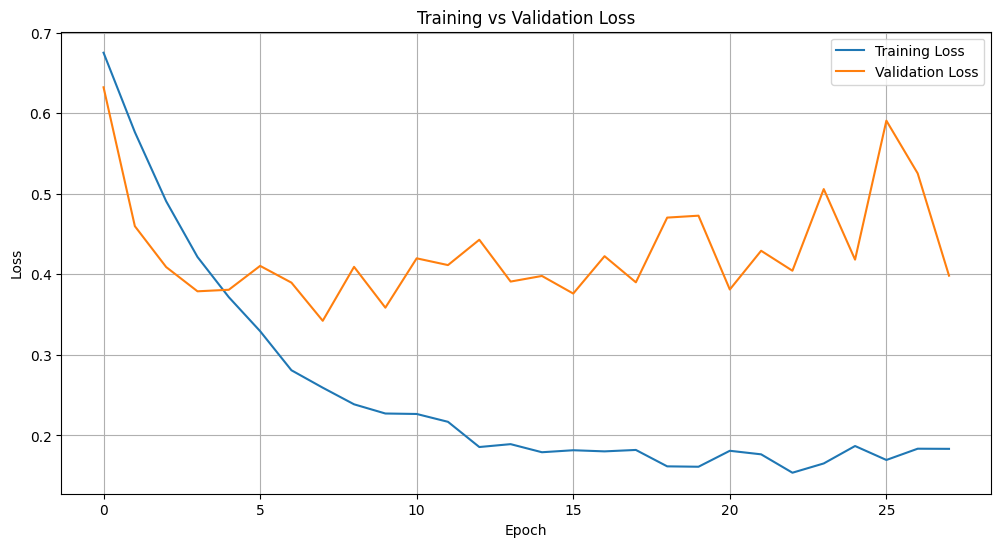

In [ ]:
# Plotting Training vs Validation Loss
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

**2. Training vs Validation Accuracy**

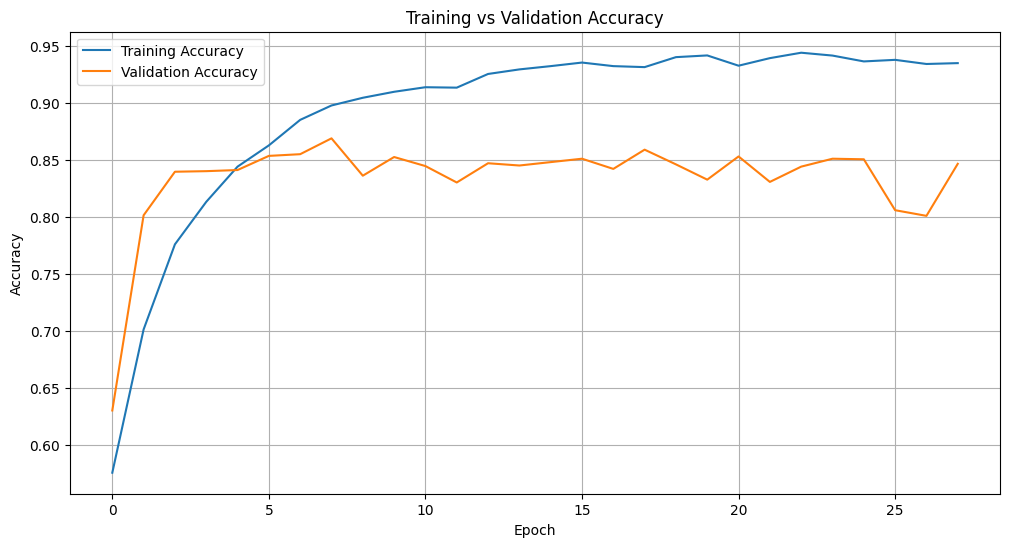

In [ ]:
# Plotting Training vs Validation Accuracy
plt.figure(figsize=(12, 6))
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

 **3. Confusion Matrix**


In [ ]:
# Load the best model
model.load_state_dict(torch.load('best_model.pt'))
model.eval() # Set model to evaluation mode

all_preds = []
all_labels = []

with torch.no_grad():
    for text, labels in val_loader:
        text = text.to(device)
        labels = labels.to(device)

        predictions = model(text)
        rounded_preds = torch.round(predictions)

        all_preds.extend(rounded_preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy().flatten())

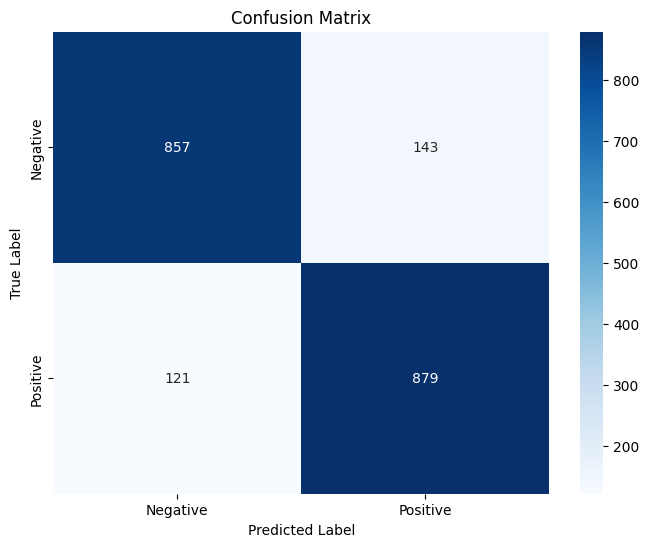

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### **Model Evaluation**


1. Loading the first 10000 test dataset

In [ ]:
# Load the full test data
full_test_texts = list(dataset["test"]["text"])
full_test_labels = list(dataset["test"]["label"])


_, test_texts, _, test_labels = train_test_split(
    full_test_texts,
    full_test_labels,
    test_size=10000, # Sample 10,000 for the test set
    random_state=42,
    stratify=full_test_labels # Ensure balanced labels in the sampled subset
)

print(f"Test texts size: {len(test_texts)}")
print(f"Test labels size: {len(test_labels)}")

Test texts size: 10000
Test labels size: 10000


2. Create dataset and dataloader for the test set

In [ ]:
test_dataset = IMDBSentimentDataset(test_texts, test_labels, seq_len)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Test dataset samples: {len(test_dataset)}")
print(f"Number of test batches: {len(test_loader)}")

Test dataset samples: 10000
Number of test batches: 157


3. Evaluate the model on the test set to get the overall test loss and accuracy.

In [ ]:
# Ensure the best model is loaded for evaluation
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

all_preds_test = []
all_labels_test = []

with torch.no_grad():
    for text, labels in test_loader:
        text = text.to(device)
        labels = labels.to(device)

        predictions = model(text)
        rounded_preds = torch.round(predictions)

        all_preds_test.extend(rounded_preds.cpu().numpy())
        all_labels_test.extend(labels.cpu().numpy())

Test Loss: 0.379 | Test Acc: 84.49%


4. Finally, Calculating Precision, Recall, and F1 Score for the test set.

In [ ]:
# Calculate Precision, Recall, F1 Score
precision = precision_score(all_labels_test, all_preds_test)
recall = recall_score(all_labels_test, all_preds_test)
f1 = f1_score(all_labels_test, all_preds_test)

print(f'Test Precision: {precision:.3f}')
print(f'Test Recall: {recall:.3f}')
print(f'Test F1 Score: {f1:.3f}')

Test Precision: 0.842
Test Recall: 0.849
Test F1 Score: 0.845
